## Imports

In [63]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import numpy as np

import cartopy.crs as ccrs
from scipy.stats import beta



### Updates (temp)

In [64]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [ ]:
is_local_data = True
month_idx = 5
safe = False
hist = 10 ### falls dank hist der Daten start unterschritten wird gibts probleme
radius = 0
end = None

In [66]:
mrsol_ds_for_mean = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)

mrsol_ds_for_var = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)

#todo nach unten setzen 
mrsol_ds_for_test = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)


In [67]:
mrsol_empirical_maximas = mrsol_ds_for_mean.max("time")

mrsol_approx_1_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_1_maximas["mrsol"] = mrsol_empirical_maximas["mrsol"] * 1.1 + 1e-5

mrsol_approx_2_maximas = mrsol_empirical_maximas.copy(deep=True)
mrsol_approx_2_maximas["mrsol"] = np.maximum(mrsol_empirical_maximas["mrsol"] * 1.05,(mrsol_empirical_maximas["depth_bnds"].isel(bnds=1)-mrsol_empirical_maximas["depth_bnds"].isel(bnds=0))*1000*0.30)

mrsol_month_empirical_maximas = model.shape_data.prune_group_ds_timespan(mrsol_ds_for_mean,Month_idx=month_idx).max("time")
mrsol_month_empirical_maximas["mrsol"] = mrsol_month_empirical_maximas["mrsol"] * 1.1 + 1e-5



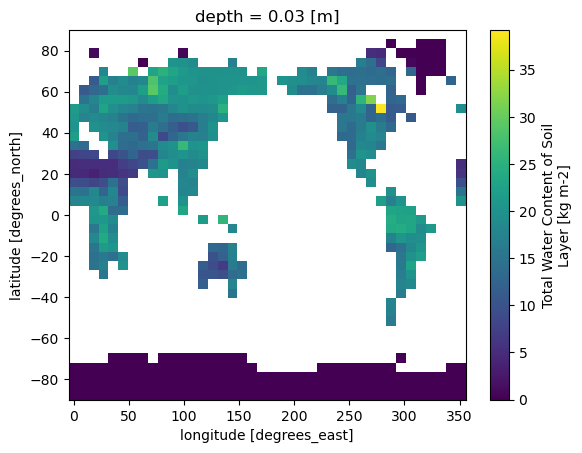

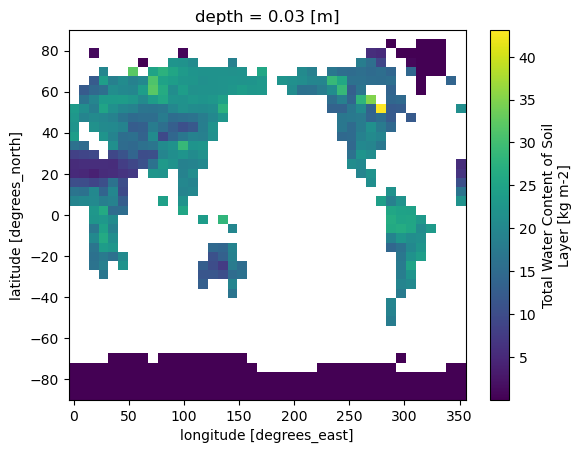

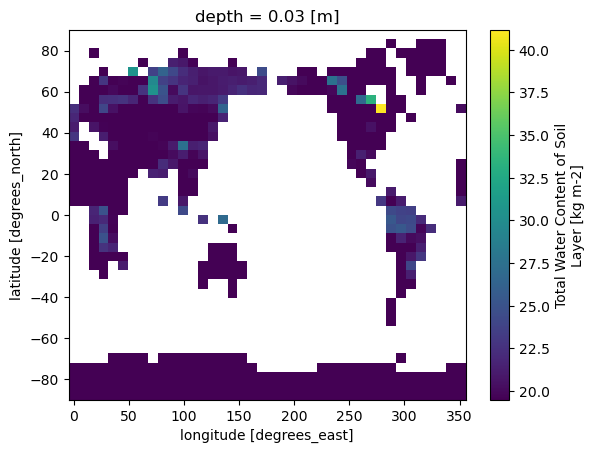

In [68]:
mrsol_empirical_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_1_maximas.isel(depth = 0).mrsol.plot(x="lon")
plt.show()
mrsol_approx_2_maximas.isel(depth = 0).mrsol.plot(x="lon");
plt.show()
mrsol_maximas = mrsol_approx_2_maximas

In [69]:
mrsol_relative_ds_for_mean = mrsol_ds_for_mean.copy(deep=True)
mrsol_relative_ds_for_mean["mrsol"] = mrsol_relative_ds_for_mean["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_var = mrsol_ds_for_var.copy(deep=True)
mrsol_relative_ds_for_var["mrsol"] = mrsol_relative_ds_for_var["mrsol"]/mrsol_maximas["mrsol"]

mrsol_relative_ds_for_test = mrsol_ds_for_test.copy(deep=True)
mrsol_relative_ds_for_test["mrsol"] = mrsol_relative_ds_for_test["mrsol"]/mrsol_maximas["mrsol"]

In [70]:
mrsol_pruned_ds_for_mean = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_mean,Month_idx=month_idx,end=end)
mrsol_pruned_ds_for_var = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_var,Month_idx=month_idx,end=end)
mrsol_pruned_ds_for_test = model.shape_data.prune_group_ds_timespan(mrsol_relative_ds_for_test,Month_idx=month_idx,end=end)

In [71]:
#mrsol_pruned_ds_for_mean.isel(depth = 4).isel(time = 90).mrsol.plot(x="lon")

In [72]:
#if radius und so
inputs = []
for i in [1,2,3]:
    tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=i).drop_vars("file_qf")
    pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=i)
    input_ds = xr.merge([tas_ds,pr_ds])
    input_ds = model.shape_data.add_hist_dimension(input_ds, hist)
    input_ds = model.shape_data.prune_group_ds_timespan(input_ds,Month_idx=month_idx,end=end)
    #input_ds = model.shape_data.add_radius_dimension(input_ds,radius)
    inputs.append(input_ds)




In [73]:
inputs[0]

<xarray.Dataset> Size: 42MB
Dimensions:  (time: 165, hist: 10, lat: 40, lon: 40)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-05-31 1851-05-31 ... 2014-05-31
  * hist     (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lat      (lat) float64 320B -87.75 -83.25 -78.75 ... 78.75 83.25 87.75
  * lon      (lon) float64 320B 0.0 9.0 18.0 27.0 ... 324.0 333.0 342.0 351.0
    height   float64 8B 2.0
Data variables:
    tas      (time, hist, lat, lon) float64 21MB 216.9 216.9 ... 271.7 271.7
    pr       (time, hist, lat, lon) float64 21MB 1.853e-06 ... 1.216e-05
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [74]:
"""
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.add_hist_dimension(tas_ds, 3)
pr_ds = model.shape_data.add_hist_dimension(pr_ds,3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_mean = xr.merge([tas_ds,pr_ds])#.drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.add_hist_dimension(tas_ds, 3)
pr_ds = model.shape_data.add_hist_dimension(pr_ds,3)

tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_var = xr.merge([tas_ds,pr_ds])#.drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.add_hist_dimension(tas_ds, 3)
pr_ds = model.shape_data.add_hist_dimension(pr_ds,3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)

input_ds_for_test = xr.merge([tas_ds,pr_ds])#.drop_vars("file_qf")
"""


'\ntas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)\npr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)\ntas_ds = model.shape_data.add_hist_dimension(tas_ds, 3)\npr_ds = model.shape_data.add_hist_dimension(pr_ds,3)\ntas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)\npr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)\n\ninput_ds_for_mean = xr.merge([tas_ds,pr_ds])#.drop_vars("file_qf")\n\ntas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)\npr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)\ntas_ds = model.shape_data.add_hist_dimension(tas_ds, 3)\npr_ds = model.shape_data.add_hist_dimension(pr_ds,3)\n\ntas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=month_idx)\npr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=month_idx)\n\ninput_ds_for_var = xr.merge([tas_ds,pr_

In [75]:
"""
def hist(ds, hist):
    history = []
    for i in range(0,hist):
        tmp = input_ds_for_mean.shift(time=i)
        history.append(tmp)

    return xr.concat(history, "hist")

data_ds
prune = model.shape_data.prune_group_ds_timespan(data_ds,Month_idx=month_idx)
prune.isel(time=50).isel(lat=30).isel(lon=30).to_array().values
"""

'\ndef hist(ds, hist):\n    history = []\n    for i in range(0,hist):\n        tmp = input_ds_for_mean.shift(time=i)\n        history.append(tmp)\n\n    return xr.concat(history, "hist")\n\ndata_ds\nprune = model.shape_data.prune_group_ds_timespan(data_ds,Month_idx=month_idx)\nprune.isel(time=50).isel(lat=30).isel(lon=30).to_array().values\n'

### Mask and Stack Data

In [99]:
inputs[0]

<xarray.Dataset> Size: 42MB
Dimensions:  (time: 165, hist: 10, lat: 40, lon: 40)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-05-31 1851-05-31 ... 2014-05-31
  * hist     (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lat      (lat) float64 320B -87.75 -83.25 -78.75 ... 78.75 83.25 87.75
  * lon      (lon) float64 320B 0.0 9.0 18.0 27.0 ... 324.0 333.0 342.0 351.0
    height   float64 8B 2.0
Data variables:
    tas      (time, hist, lat, lon) float64 21MB 216.9 216.9 ... 271.7 271.7
    pr       (time, hist, lat, lon) float64 21MB 1.853e-06 ... 1.216e-05
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [76]:
mrsol_masked_ds_for_mean, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_mean.drop_vars("depth_bnds"))
input_masked_ds_for_mean = model.mask.mask_mask(inputs[0],chunk_mask)

mrsol_masked_ds_for_var , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_var.drop_vars("depth_bnds"))
input_masked_ds_for_var = model.mask.mask_mask(inputs[1],chunk_mask)

mrsol_masked_ds_for_test, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(mrsol_pruned_ds_for_test.drop_vars("depth_bnds"))
input_masked_ds_for_test = model.mask.mask_mask(inputs[2],chunk_mask)

mrsol_maximas_masked = model.mask.mask_mask(mrsol_maximas,chunk_mask)

In [ ]:
#input_masked_ds_for_mean 2019835

In [ ]:
#np.isnan(input_masked_ds_for_mean.isel(hist=4)).sum()

<xarray.Dataset> Size: 32B
Dimensions:  ()
Coordinates:
    height   float64 8B 2.0
    hist     int64 8B 4
Data variables:
    tas      int64 8B 201795
    pr       int64 8B 201795
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [77]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [137]:
mrsol_stack_ds_for_mean = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_mean)
mrsol_stack_ds_for_var = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_var)
mrsol_stack_ds_for_test = mesmer.grid.stack_lat_lon(mrsol_masked_ds_for_test)
input_stack_ds_for_mean = mesmer.grid.stack_lat_lon(input_masked_ds_for_mean,dropna=False)
input_stack_ds_for_var = mesmer.grid.stack_lat_lon(input_masked_ds_for_var)
input_stack_ds_for_test = mesmer.grid.stack_lat_lon(input_masked_ds_for_test)
mrsol_maximas_stack = mesmer.grid.stack_lat_lon(mrsol_maximas_masked)

In [158]:
valid = input_stack_ds_for_mean.sel(hist=0).notnull()
valid = valid.broadcast_like(input_stack_ds_for_mean)
input_stack_ds_for_mean = input_stack_ds_for_mean.where(valid, drop=True)

In [160]:
input_stack_ds_for_mean

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 165, hist: 10, gridcell: 377)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-05-31 1851-05-31 ... 2014-05-31
  * hist     (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 144.0 ... 99.0 270.0 279.0
    height   float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    tas      (time, hist, gridcell) float64 5MB 273.3 273.6 ... 272.9 271.9
    pr       (time, hist, gridcell) float64 5MB 2.919e-05 ... 7.557e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [152]:
valid_gridcells = input_stack_ds_for_mean.sel(hist=0).dropna("gridcell")
#input_stack_ds_for_mean = input_stack_ds_for_mean.sel(gridcell=valid_gridcells)
input_stack_ds_for_mean.sel(gridcell = [0,10])
input_stack_ds_for_mean.gridcell

<xarray.DataArray 'gridcell' (gridcell: 1600)> Size: 13kB
[1600 values with dtype=int64]
Coordinates:
    lat      (gridcell) float64 13kB -87.75 -87.75 -87.75 ... 87.75 87.75 87.75
    lon      (gridcell) float64 13kB 0.0 9.0 18.0 27.0 ... 333.0 342.0 351.0
    height   float64 8B 2.0
Dimensions without coordinates: gridcell

In [127]:
input_stack_ds_for_mean = input_stack_ds_for_mean.dropna("gridcell")

In [128]:
input_stack_ds_for_mean

<xarray.Dataset> Size: 1kB
Dimensions:  (hist: 10, time: 165, gridcell: 0)
Coordinates:
  * hist     (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
  * time     (time) datetime64[ns] 1kB 1850-05-31 1851-05-31 ... 2014-05-31
    lat      (gridcell) float64 0B 
    lon      (gridcell) float64 0B 
    height   float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    tas      (time, hist, gridcell) float64 0B 
    pr       (time, hist, gridcell) float64 0B 
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

### Transform Data

In [79]:
#Normierung, da Betaverteilung zwischen 0 und 1 gefittet wird (für Betaverteilung sollte die Transformation vor dro vars depth bnds, mask und stack sitzen)
#porosität von 0.35 bis 0.6 annehmen
#schauen ob es Modelle hat mit ähnlicher datenstruktur aber mit porösität?

In [80]:
mrsol_t_for_mean = model.transform.none_Transform_ds(mrsol_stack_ds_for_mean)
mrsol_t_for_var = model.transform.none_Transform_ds(mrsol_stack_ds_for_var)
mrsol_t_for_test = model.transform.none_Transform_ds(mrsol_stack_ds_for_test)

### Linear Regression of the mean

In [81]:
inputs[0]

<xarray.Dataset> Size: 42MB
Dimensions:  (time: 165, hist: 10, lat: 40, lon: 40)
Coordinates:
  * time     (time) datetime64[ns] 1kB 1850-05-31 1851-05-31 ... 2014-05-31
  * hist     (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
  * lat      (lat) float64 320B -87.75 -83.25 -78.75 ... 78.75 83.25 87.75
  * lon      (lon) float64 320B 0.0 9.0 18.0 27.0 ... 324.0 333.0 342.0 351.0
    height   float64 8B 2.0
Data variables:
    tas      (time, hist, lat, lon) float64 21MB 216.9 216.9 ... 271.7 271.7
    pr       (time, hist, lat, lon) float64 21MB 1.853e-06 ... 1.216e-05
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:13:55 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/6b679cba-17b8-45eb-90dc-23d170c1998c
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  44b9ee9e68daceb1f50e9680dcfb7744f0e272d73c5e18...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [82]:
mean_predictors = input_stack_ds_for_mean
mean_target_da = mrsol_t_for_mean.mrsol

In [83]:
LinReg_mean = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["hist"])

In [84]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [85]:
LinReg_mean.params


<xarray.DataArray 'tas' (predictor_var: 2, time: 165, hist: 10, gridcell: 0)> Size: 0B
array([], shape=(2, 165, 10, 0), dtype=float64)
Coordinates:
  * predictor_var  (predictor_var) <U3 24B 'tas' 'pr'
  * time           (time) datetime64[ns] 1kB 1850-05-31 ... 2014-05-31
  * hist           (hist) int64 80B 0 1 2 3 4 5 6 7 8 9
    lat            (gridcell) float64 0B 
    lon            (gridcell) float64 0B 
    height         float64 8B 2.0
Dimensions without coordinates: gridcell
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [86]:
"""out = LinReg_mean.params[0]
predictors_concat = LinReg_mean.params[1]
predictors_stack = LinReg_mean.params[2]
target = LinReg_mean.params[3]"""

'out = LinReg_mean.params[0]\npredictors_concat = LinReg_mean.params[1]\npredictors_stack = LinReg_mean.params[2]\ntarget = LinReg_mean.params[3]'

In [87]:
"""location_dim="gridcell"
predictor_dims=["lat_translations","lon_translations","hist"]
regr_dim = "time"
(target_dim,) = list(set(target.dims) - {location_dim,regr_dim})"""

'location_dim="gridcell"\npredictor_dims=["lat_translations","lon_translations","hist"]\nregr_dim = "time"\n(target_dim,) = list(set(target.dims) - {location_dim,regr_dim})'

In [88]:
"""intersept = xr.DataArray(
    out[:,:,0],
    dims=(location_dim, target_dim),
    coords={
        location_dim: target.coords[location_dim],
        target_dim: target.coords[target_dim]
    }
)"""

'intersept = xr.DataArray(\n    out[:,:,0],\n    dims=(location_dim, target_dim),\n    coords={\n        location_dim: target.coords[location_dim],\n        target_dim: target.coords[target_dim]\n    }\n)'

In [89]:
"""result = xr.DataArray(
    out[:,:,1:],
    dims=(location_dim, target_dim, "predictor"),
    coords={
        location_dim: target.coords[location_dim],
        target_dim: target.coords[target_dim],
        "predictor": predictors_stack.coords["predictor"],
    },
)"""

'result = xr.DataArray(\n    out[:,:,1:],\n    dims=(location_dim, target_dim, "predictor"),\n    coords={\n        location_dim: target.coords[location_dim],\n        target_dim: target.coords[target_dim],\n        "predictor": predictors_stack.coords["predictor"],\n    },\n)'

In [90]:
"""result = result.unstack("predictor")
result = result.to_dataset(dim="predictor_var")"""

'result = result.unstack("predictor")\nresult = result.to_dataset(dim="predictor_var")'

In [91]:
"""result
keys = ["intercept"] + list(predictors_stack.coords["predictor"].values)
data_vars = {key: ((location_dim,target_dim), out[:,:, i]) for i, key in enumerate(keys)}
result = xr.Dataset(data_vars, coords=target.coords)


result["fit_intercept"] = True

result.squeeze()
keys = ["intercept"] + list(predictors_stack.coords["predictor"].values)
data_vars = {key: ((location_dim,target_dim), out[:,:, i]) for i, key in enumerate(keys)}
result = xr.Dataset(data_vars, coords=target.coords)

result["fit_intercept"] = True

result.squeeze()
#LinReg_mean.params"""

'result\nkeys = ["intercept"] + list(predictors_stack.coords["predictor"].values)\ndata_vars = {key: ((location_dim,target_dim), out[:,:, i]) for i, key in enumerate(keys)}\nresult = xr.Dataset(data_vars, coords=target.coords)\n\n\nresult["fit_intercept"] = True\n\nresult.squeeze()\nkeys = ["intercept"] + list(predictors_stack.coords["predictor"].values)\ndata_vars = {key: ((location_dim,target_dim), out[:,:, i]) for i, key in enumerate(keys)}\nresult = xr.Dataset(data_vars, coords=target.coords)\n\nresult["fit_intercept"] = True\n\nresult.squeeze()\n#LinReg_mean.params'

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [92]:
var_predictors = input_stack_ds_for_var
var_target_ds = mrsol_t_for_var

In [93]:
LinReg_mean.predict(var_predictors)

AttributeError: 'DataArray' object has no attribute 'data_vars'

In [ ]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [ ]:
residuals_t

<xarray.Dataset> Size: 2MB
Dimensions:           (depth: 5, time: 165, gridcell: 377)
Coordinates:
  * depth             (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time              (time) datetime64[ns] 1kB 1850-05-31 ... 2014-05-31
  * gridcell          (gridcell) int64 3kB 0 1 2 3 4 5 ... 372 373 374 375 376
    lat               (gridcell) float64 3kB -51.75 -47.25 ... 78.75 78.75
    lon               (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0
    height            float64 8B 2.0
    lat_translations  int64 8B 0
    lon_translations  int64 8B 0
Data variables:
    residuals         (time, depth, gridcell) float64 2MB -0.00469 ... 2.711e-19

### Linear Regression of the Variance

In [ ]:
LinReg_variance = model.stats._parallel_linear_regression_stack.ParLinearRegressionStack(predictor_dims=["lat_translations","lon_translations","hist"])

In [ ]:
LinReg_variance.fit(predictors=mean_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [ ]:
LinReg_mean.params

<xarray.Dataset> Size: 169kB
Dimensions:           (gridcell: 377, depth: 5, hist: 5)
Coordinates:
  * gridcell          (gridcell) int64 3kB 0 1 2 3 4 5 ... 372 373 374 375 376
  * depth             (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * hist              (hist) int64 40B 0 1 2 3 4
    lat_translations  int64 8B 0
    lon_translations  int64 8B 0
Data variables:
    tas               (gridcell, depth, hist) float64 75kB 0.0008191 ... -9.0...
    pr                (gridcell, depth, hist) float64 75kB 684.5 ... 4.867e-27
    intercept         (gridcell, depth) float64 15kB 1.096 1.522 ... 0.0001

In [ ]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression_stack.ParLinearRegressionStack at 0x7f043ae8bb60>,
 <model.stats._parallel_linear_regression_stack.ParLinearRegressionStack at 0x7f0422f4d810>)

### Export Prameters

In [ ]:
if False:
    model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform", name=f"month_idx= {month_idx}")

In [ ]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log_transform")

### Example Emulation

In [ ]:
test_predictors = input_stack_ds_for_test
test_target_ds_t = mrsol_t_for_test.transpose("gridcell","time", "depth")

In [ ]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [ ]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

### crps(s) Score

In [ ]:
#temp
importlib.reload(model_analysis.crps_score);

In [ ]:
mean = test_mean_prediction_stacked.copy(deep=True)
var = test_var_prediction_stacked.copy(deep=True)

#todo precision parameter in guter Quelle finden
precision = (mean*(1-mean))/var-1

test_alpha_prediction_stacked = mean*precision
test_beta_prediction_stacked = (1-mean)*precision

In [ ]:
maximas = mrsol_maximas_stack.drop_vars("depth_bnds").transpose("gridcell","depth")


In [ ]:
maximas

<xarray.Dataset> Size: 21kB
Dimensions:  (depth: 5, gridcell: 377)
Coordinates:
  * depth    (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    lat      (gridcell) float64 3kB -51.75 -47.25 -42.75 ... 78.75 78.75 78.75
    lon      (gridcell) float64 3kB 288.0 288.0 288.0 144.0 ... 99.0 270.0 279.0
Dimensions without coordinates: gridcell
Data variables:
    mrsol    (gridcell, depth) float64 15kB 19.5 76.2 273.9 ... 870.6 1.71e+03
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [ ]:
test_alpha_prediction_stacked

<xarray.Dataset> Size: 2MB
Dimensions:           (time: 165, gridcell: 377, depth: 5)
Coordinates:
  * time              (time) datetime64[ns] 1kB 1850-05-31 ... 2014-05-31
  * gridcell          (gridcell) int64 3kB 0 1 2 3 4 5 ... 372 373 374 375 376
    lat               (gridcell) float64 3kB -51.75 -47.25 ... 78.75 78.75
    lon               (gridcell) float64 3kB 288.0 288.0 288.0 ... 270.0 279.0
  * depth             (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height            float64 8B 2.0
    lat_translations  int64 8B 0
    lon_translations  int64 8B 0
Data variables:
    prediction        (gridcell, time, depth) float64 2MB 2.4e+03 ... 9.999e+23

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [ ]:
crps_score_stacked, space_crps_score_stacked = model_analysis.crps_score.crps_beta_ensemble_score(test_alpha_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32), test_beta_prediction_stacked.isel(depth=slice(0,3)).clip(min=1e-32),test_target_ds_t.isel(depth=slice(0,3)),transformation="rel",mrsol_maximas=maximas,ensemble_size=15)

for both of the scors we can calculate a crpss score against the time constant mean, for the score of the backtransposed data, we need to make a non-transposed target.

In [ ]:

test_target_ds = test_target_ds_t.copy(deep=True) 
test_target_ds["mrsol"] = test_target_ds_t["mrsol"] * maximas["mrsol"]


In [ ]:
scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(crps_score_stacked,test_target_ds) 

In [ ]:
space_scores_stacked = model_analysis.crps_score.add_crpss_against_mean_ensemble_score(space_crps_score_stacked,test_target_ds_t) 

To visualize the results we bring it back to the lat lon grid form. Ausserdem entnehmen wir die Stellen wieder, die mit threshholds aufgefüllt wurden

In [ ]:
scores = mesmer.grid.unstack_lat_lon_and_align(scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))
space_scores = mesmer.grid.unstack_lat_lon_and_align(space_scores_stacked,mrsol_masked_ds_for_mean.isel(depth=slice(0,2)))

In [ ]:
scores = model.mask.mask_mask(scores,detail_mask_mean, "lon","lat", "depth")
space_scores = model.mask.mask_mask(space_scores,detail_mask_mean, "lon","lat", "depth")

In [ ]:
scores.isel(lat=21,lon=32,depth=0).mean("time").crps_score


<xarray.DataArray 'crps_score' ()> Size: 8B
array(0.17977857)
Coordinates:
    lon      float64 8B 288.0
    lat      float64 8B 6.75
    depth    float64 8B 0.03

Globale Score übersicht

Text(0.5, 1.0, 'crpss_score against const mean')

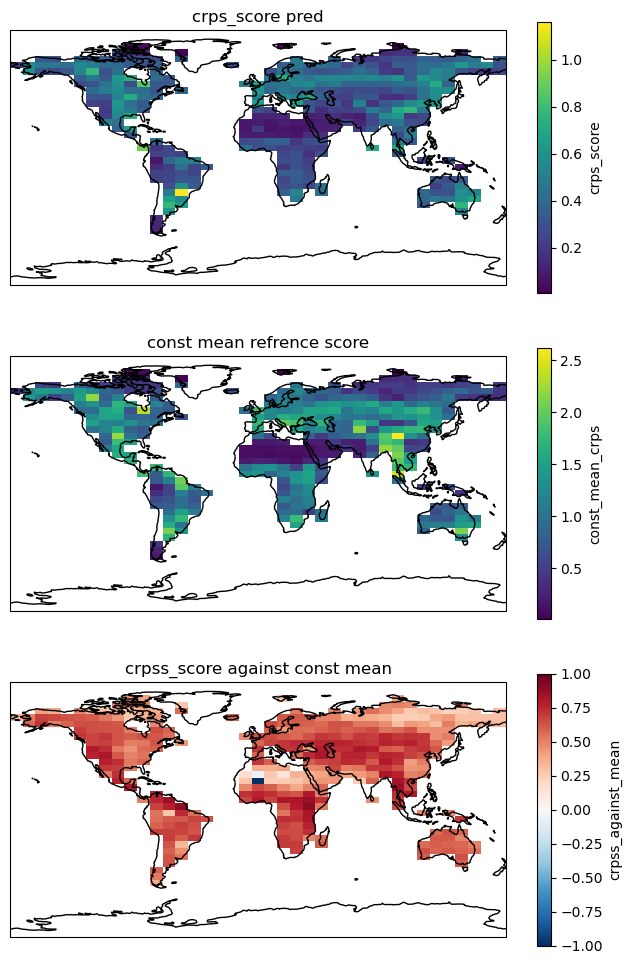

In [ ]:
fig_global_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)
depth = 0

da = scores.isel(depth=depth).mean("time").crps_score#.clip(max=2)
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("crps_score pred")

da = scores.isel(depth=depth).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence score")

da = scores.isel(depth=depth).mean("time").crpss_against_mean.clip(min=-1)
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("crpss_score against const mean")



Text(0.5, 1.0, 'space_crpss_score against const mean')

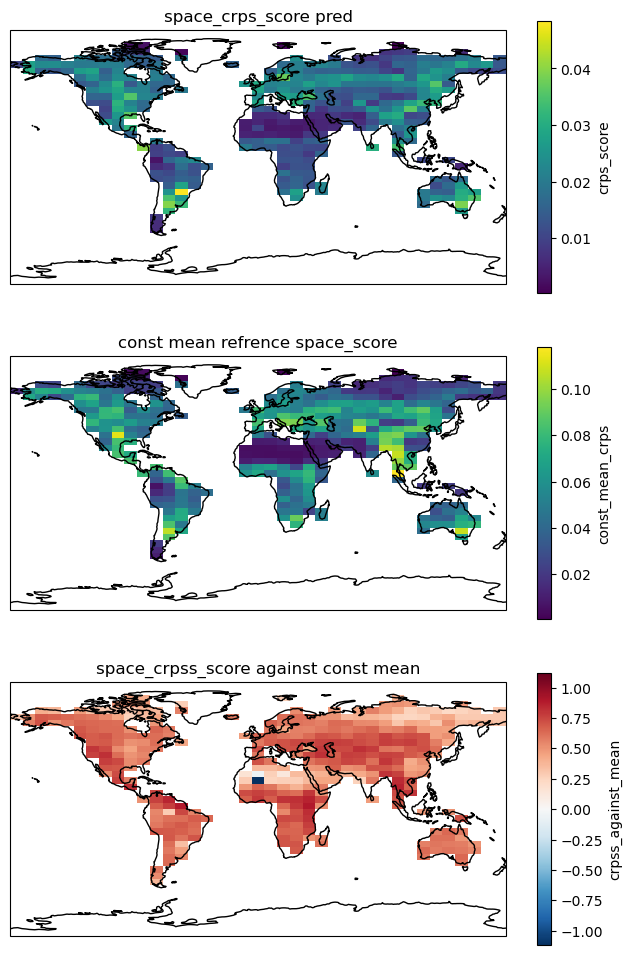

In [ ]:
fig_global_space_crpss, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()},
    nrows=3,
    ncols=1,
    figsize=(8, 12)
)

da = space_scores.isel(depth=0).mean("time").crps_score
da.plot(ax=ax[0])
ax[0].coastlines()
ax[0].set_title("space_crps_score pred")

da = space_scores.isel(depth=0).mean("time").const_mean_crps
da.plot(ax=ax[1])
ax[1].coastlines()
ax[1].set_title("const mean refrence space_score")

da = space_scores.isel(depth=0).mean("time").crpss_against_mean
da.plot(ax=ax[2])
ax[2].coastlines()
ax[2].set_title("space_crpss_score against const mean")



Locale Zeit reihe

In [ ]:
#Amazonas  ca. 3° S, 65° W

In [ ]:
#scores.sel(lat= -3, lon = 295, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

In [ ]:
#irgendwo in Russland

In [ ]:
#scores.sel(lat= 60, lon = 100, method="nearest").isel(depth = 0).to_array().plot.line(hue="variable", x = "time");

### Save results

In [ ]:
if safe:
    model.save.save_crps_scores(space_scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name=f"approx_mon_emp11_month_idx = {month_idx}",name_postfix="")
    model.save.save_crps_scores(scores, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist",name=f"approx_mon_emp11_month_idx = {month_idx}", name_postfix="back_transformed")
    model.save.save_plot(fig_global_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_crpss_clipped_month_idx = {month_idx}_approx_mon_emp11")
    model.save.save_plot(fig_global_space_crpss, var= "mrsol", scen = "historical", folder = "MPI-ESM1-2-LR/Beta_dist", name = f"fig_global_space_crpss__month_idx = {month_idx}_approx_mon_emp11")